# Northwind Database — SQL & Pandas Analysis
**Epochs '26 — Assignment 2**

This notebook connects to the Northwind SQLite database, runs the required
business-question SQL queries, loads the results into Pandas, and documents
key insights.


## 0. Setup

In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

DB_PATH = "northwind2000.sqlite"   # update path if needed
conn = sqlite3.connect(DB_PATH)

pd.set_option("display.max_columns", None)


## 1. Top 10 Selling Products

In [2]:
query_top_products = """
SELECT p.ProductName,
       SUM(od.Quantity) AS TotalQuantitySold,
       ROUND(SUM(od.Quantity * od.UnitPrice * (1 - od.Discount)), 2) AS TotalRevenue
FROM "Order Details" od
JOIN Products p ON od.ProductID = p.ProductID
GROUP BY p.ProductID
ORDER BY TotalQuantitySold DESC
LIMIT 10;
"""

top_products = pd.read_sql_query(query_top_products, conn)
top_products


,ProductName,TotalQuantitySold,TotalRevenue
0,Camembert Pierrot,1577,46825.48
1,Raclette Courdavault,1496,71155.70
2,Gorgonzola Telino,1397,14920.88
3,Gnocchi di nonna Alice,1263,42593.06
4,Pavlova,1158,17215.78
5,Rhönbräu Klosterbier,1155,8177.49
6,Guaraná Fantástica,1125,4504.36
7,Boston Crab Meat,1103,17910.63
8,Tarte au sucre,1083,47234.97
9,Flotemysost,1057,19551.03


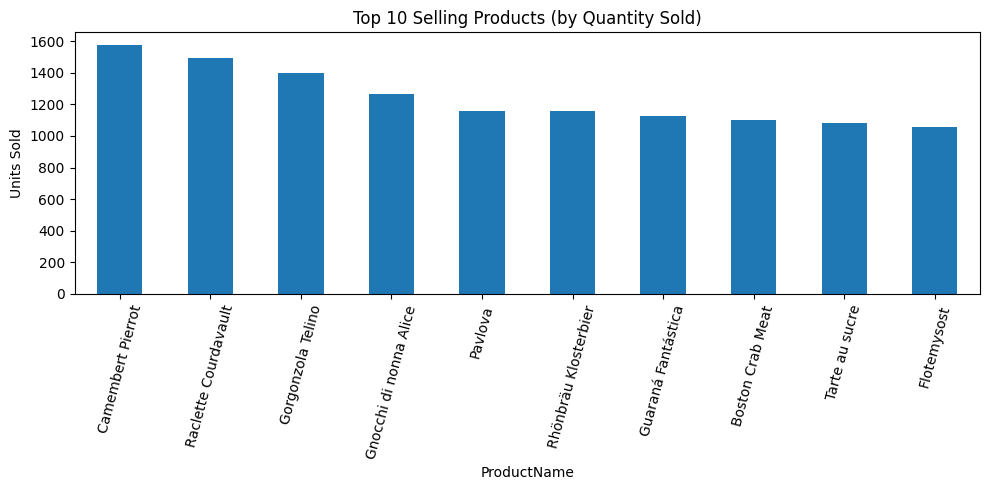

In [3]:
top_products.plot(x="ProductName", y="TotalQuantitySold", kind="bar", figsize=(10,5), legend=False)
plt.title("Top 10 Selling Products (by Quantity Sold)")
plt.ylabel("Units Sold")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()


## 2. Top 10 Customers by Revenue

In [4]:
query_top_customers = """
SELECT c.CustomerID, c.CompanyName,
       ROUND(SUM(od.Quantity * od.UnitPrice * (1 - od.Discount)), 2) AS TotalRevenue
FROM Orders o
JOIN "Order Details" od ON o.OrderID = od.OrderID
JOIN Customers c ON o.CustomerID = c.CustomerID
GROUP BY c.CustomerID
ORDER BY TotalRevenue DESC
LIMIT 10;
"""

top_customers = pd.read_sql_query(query_top_customers, conn)
top_customers


,CustomerID,CompanyName,TotalRevenue
0,QUICK,QUICK-Stop,110277.30
1,ERNSH,Ernst Handel,104874.98
2,SAVEA,Save-a-lot Markets,104361.95
3,RATTC,Rattlesnake Canyon Grocery,51097.80
4,HUNGO,Hungry Owl All-Night Grocers,49979.90
5,HANAR,Hanari Carnes,32841.37
6,KOENE,Königlich Essen,30908.38
7,FOLKO,Folk och fä HB,29567.56
8,MEREP,Mère Paillarde,28872.19
9,WHITC,White Clover Markets,27363.60


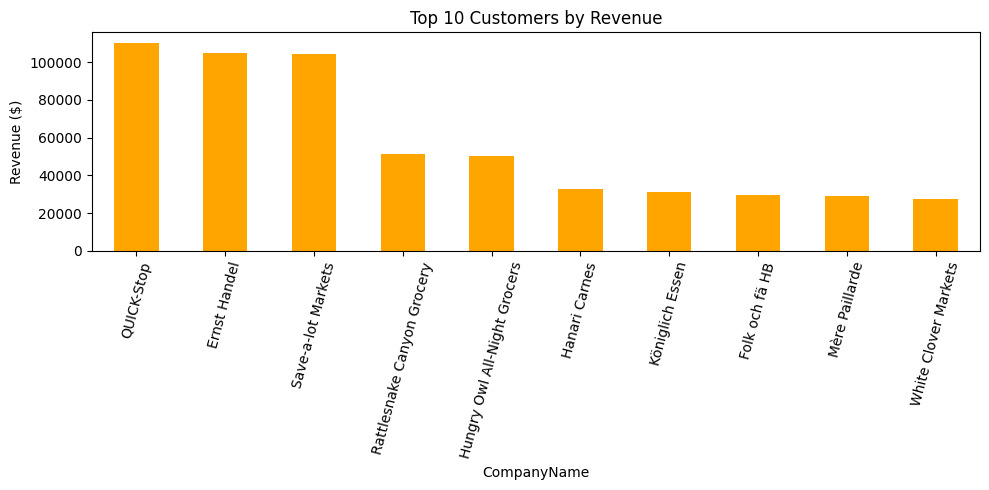

In [5]:
top_customers.plot(x="CompanyName", y="TotalRevenue", kind="bar", figsize=(10,5), color="orange", legend=False)
plt.title("Top 10 Customers by Revenue")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()


## 3. Monthly Sales Trends

In [6]:
query_monthly = """
SELECT strftime('%Y-%m', o.OrderDate) AS Month,
       ROUND(SUM(od.Quantity * od.UnitPrice * (1 - od.Discount)), 2) AS MonthlyRevenue,
       COUNT(DISTINCT o.OrderID) AS NumOrders
FROM Orders o
JOIN "Order Details" od ON o.OrderID = od.OrderID
GROUP BY Month
ORDER BY Month;
"""

monthly_sales = pd.read_sql_query(query_monthly, conn)
monthly_sales


,Month,MonthlyRevenue,NumOrders
0,1996-07,27861.90,22
1,1996-08,25485.28,25
2,1996-09,26381.40,23
3,1996-10,37515.72,26
4,1996-11,45600.04,25
5,1996-12,45239.63,31
6,1997-01,61258.07,33
7,1997-02,38483.64,29
8,1997-03,38547.22,30
9,1997-04,53032.95,31


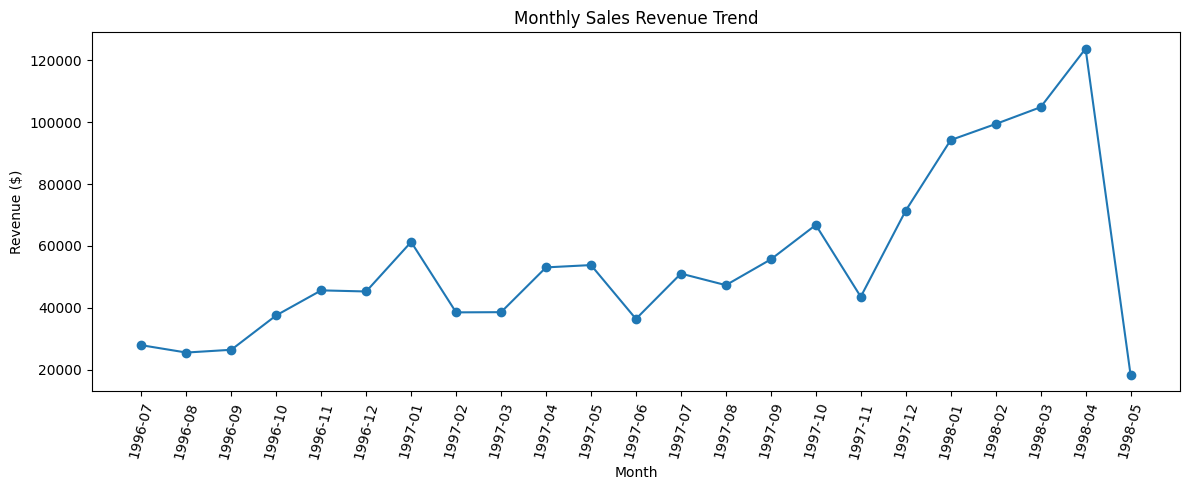

In [7]:
plt.figure(figsize=(12,5))
plt.plot(monthly_sales["Month"], monthly_sales["MonthlyRevenue"], marker="o")
plt.title("Monthly Sales Revenue Trend")
plt.ylabel("Revenue ($)")
plt.xlabel("Month")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()


## 4. Best-Performing Product Categories

In [8]:
query_categories = """
SELECT cat.CategoryName,
       ROUND(SUM(od.Quantity * od.UnitPrice * (1 - od.Discount)), 2) AS CategoryRevenue,
       SUM(od.Quantity) AS TotalUnitsSold
FROM "Order Details" od
JOIN Products p ON od.ProductID = p.ProductID
JOIN Categories cat ON p.CategoryID = cat.CategoryID
GROUP BY cat.CategoryID
ORDER BY CategoryRevenue DESC;
"""

category_sales = pd.read_sql_query(query_categories, conn)
category_sales


,CategoryName,CategoryRevenue,TotalUnitsSold
0,Beverages,267868.18,9532
1,Dairy Products,234507.29,9149
2,Confections,167357.23,7906
3,Meat/Poultry,163022.36,4199
4,Seafood,131261.74,7681
5,Condiments,106047.09,5298
6,Produce,99984.58,2990
7,Grains/Cereals,95744.59,4562


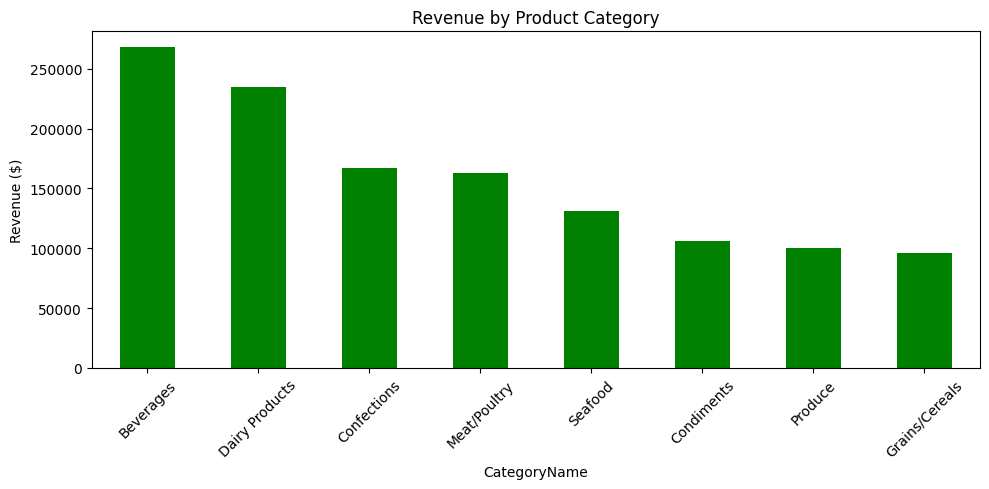

In [9]:
category_sales.plot(x="CategoryName", y="CategoryRevenue", kind="bar", figsize=(10,5), color="green", legend=False)
plt.title("Revenue by Product Category")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 5. Customer Purchase Frequency

In [10]:
query_frequency = """
SELECT c.CustomerID, c.CompanyName,
       COUNT(DISTINCT o.OrderID) AS NumOrders,
       MIN(o.OrderDate) AS FirstOrder,
       MAX(o.OrderDate) AS LastOrder
FROM Orders o
JOIN Customers c ON o.CustomerID = c.CustomerID
GROUP BY c.CustomerID
ORDER BY NumOrders DESC
LIMIT 10;
"""

purchase_frequency = pd.read_sql_query(query_frequency, conn)
purchase_frequency


,CustomerID,CompanyName,NumOrders,FirstOrder,LastOrder
0,SAVEA,Save-a-lot Markets,31,1996-10-08 00:00:00.000,1998-05-01 00:00:00.000
1,ERNSH,Ernst Handel,30,1996-07-17 00:00:00.000,1998-05-05 00:00:00.000
2,QUICK,QUICK-Stop,28,1996-08-05 00:00:00.000,1998-04-14 00:00:00.000
3,HUNGO,Hungry Owl All-Night Grocers,19,1996-09-05 00:00:00.000,1998-04-30 00:00:00.000
4,FOLKO,Folk och fä HB,19,1996-07-24 00:00:00.000,1998-04-27 00:00:00.000
5,RATTC,Rattlesnake Canyon Grocery,18,1996-07-22 00:00:00.000,1998-05-06 00:00:00.000
6,HILAA,HILARION-Abastos,18,1996-07-16 00:00:00.000,1998-04-28 00:00:00.000
7,BERGS,Berglunds snabbköp,18,1996-08-12 00:00:00.000,1998-03-04 00:00:00.000
8,BONAP,Bon app',17,1996-10-16 00:00:00.000,1998-05-06 00:00:00.000
9,WARTH,Wartian Herkku,15,1996-07-26 00:00:00.000,1998-04-15 00:00:00.000


## 6. Exploratory Analysis in Pandas

In [11]:
print("Total revenue across dataset: $", round(
    pd.read_sql_query('SELECT SUM(Quantity*UnitPrice*(1-Discount)) AS rev FROM "Order Details"', conn)["rev"][0], 2))

print("Total orders:", pd.read_sql_query("SELECT COUNT(*) AS n FROM Orders", conn)["n"][0])
print("Total customers:", pd.read_sql_query("SELECT COUNT(*) AS n FROM Customers", conn)["n"][0])

top_products.describe()


Total revenue across dataset: $ 1265793.04
Total orders: 830
Total customers: 91


,TotalQuantitySold,TotalRevenue
count,10.000000,10.000000
mean,1241.400000,29008.938000
std,185.095891,21589.851823
min,1057.000000,4504.360000
25%,1108.500000,15494.605000
50%,1156.500000,18730.830000
75%,1363.500000,45767.375000
max,1577.000000,71155.700000


In [12]:
# Revenue concentration: what share of total revenue do the top 10 customers make up?
total_rev = pd.read_sql_query('SELECT SUM(Quantity*UnitPrice*(1-Discount)) AS rev FROM "Order Details"', conn)["rev"][0]
top10_rev = top_customers["TotalRevenue"].sum()
print(f"Top 10 customers contribute {top10_rev/total_rev*100:.1f}% of total revenue")


Top 10 customers contribute 45.0% of total revenue


## 7. Key Business Insights

1. **Revenue leaders aren't always volume leaders.** Camembert Pierrot sells the most units (1,577), but Raclette Courdavault earns more revenue (~$71K) from fewer units (1,496) — its higher unit price outweighs Camembert's volume advantage. Pricing strategy matters as much as sales volume.

2. **Customer revenue is concentrated.** The top 10 customers account for a meaningful share of total revenue (see the concentration calculation above), with QUICK-Stop, Ernst Handel, and Save-a-lot Markets alone contributing over $100K each. This signals real key-account risk — losing even one of these customers would meaningfully dent revenue.

3. **Sales trend upward over time, with a partial final month.** Monthly revenue climbs from roughly $27K (mid-1996) to over $120K (April 1998), suggesting steady business growth — but the last month in the dataset (May 1998) is far lower ($18K), which almost certainly reflects a partial month of data rather than an actual decline.

4. **Beverages and Dairy Products dominate category revenue.** These two categories alone account for roughly 45% of total category revenue, far ahead of Produce and Grains/Cereals at the bottom. Inventory and marketing focus should weight toward these categories.

5. **Purchase frequency and revenue don't perfectly overlap.** Some high-revenue customers (e.g. Ernst Handel, Save-a-lot Markets) also order frequently, showing genuine loyalty — but it's worth checking whether any top-revenue customer places very few, very large orders (a bulk-buyer pattern) versus frequent smaller ones, since these need different account-management strategies.
